In [1]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "../TinyMLGNSS/logs/nmea_clean_20260815_173103_features.csv"

df = pd.read_csv(CSV_PATH)


def nmea_time_to_seconds(fix_time):
    """Convert NMEA HHMMSS.ss (as float or string) to seconds since midnight."""
    s = fix_time.astype(str).str.split(".").str[0].str.zfill(6)
    frac = fix_time.astype(float) % 1
    hh = s.str[0:2].astype(int)
    mm = s.str[2:4].astype(int)
    ss = s.str[4:6].astype(int)
    return hh * 3600 + mm * 60 + ss + frac


df["time_sec"] = nmea_time_to_seconds(df["fix_time"])
df["elapsed_s"] = df["time_sec"] - df["time_sec"].iloc[0]

df.head()

,fix_time,mean_snr,max_snr,var_snr,hdop,pdop,tracked_satellites,fix_quality,delta_mean_snr,rolling_var_snr,time_sec,elapsed_s
0,153104.0,25.2,39.0,106.76,1.06,2.08,9,1,0.0,0.000,55864.0,0.0
1,153105.0,25.4,39.0,94.24,1.06,2.08,9,1,0.2,0.010,55865.0,1.0
2,153106.0,25.4,37.0,83.64,1.06,2.08,9,1,0.0,0.009,55866.0,2.0
3,153107.0,25.4,39.0,96.44,1.06,2.08,9,1,0.0,0.007,55867.0,3.0
4,153108.0,25.8,41.0,106.36,1.06,2.08,9,1,0.4,0.038,55868.0,4.0


In [2]:
print(df.describe())
print()
print(df.head())

            fix_time     mean_snr      max_snr      var_snr         hdop  \
count    1816.000000  1816.000000  1816.000000  1816.000000  1816.000000   
mean   154775.817181    25.879504    42.379956   101.556388     1.153392   
std      1396.163800     1.619168     1.883352    20.986144     0.164210   
min    153104.000000    21.182000    37.000000    43.690000     1.040000   
25%    153837.750000    24.800000    41.000000    88.222000     1.060000   
50%    154611.500000    25.889000    43.000000    99.430500     1.090000   
75%    155345.250000    27.000000    44.000000   114.245750     1.140000   
max    160119.000000    31.000000    47.000000   169.062000     2.520000   

              pdop  tracked_satellites  fix_quality  delta_mean_snr  \
count  1816.000000         1816.000000       1816.0     1816.000000   
mean      2.144526            8.417401          1.0       -0.000354   
std       0.265306            0.652864          0.0        0.597282   
min       1.730000            6

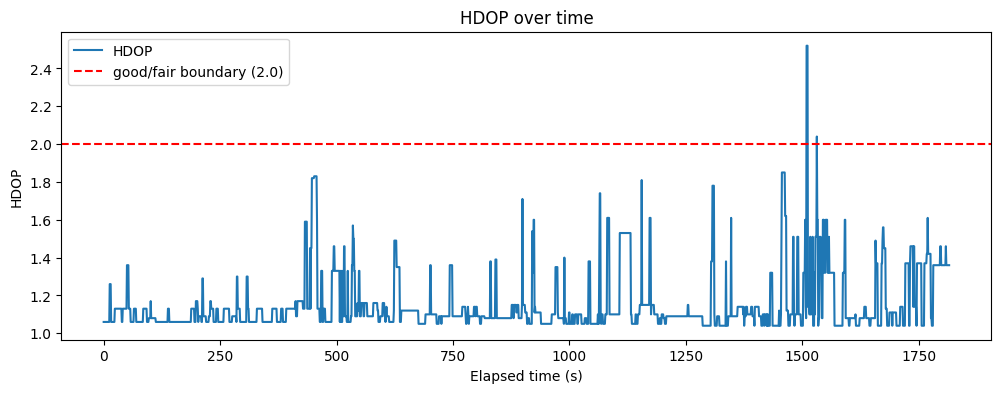

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["elapsed_s"], df["hdop"], label="HDOP")
ax.axhline(2.0, color="red", linestyle="--", label="good/fair boundary (2.0)")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("HDOP")
ax.set_title("HDOP over time")
ax.legend()
plt.show()

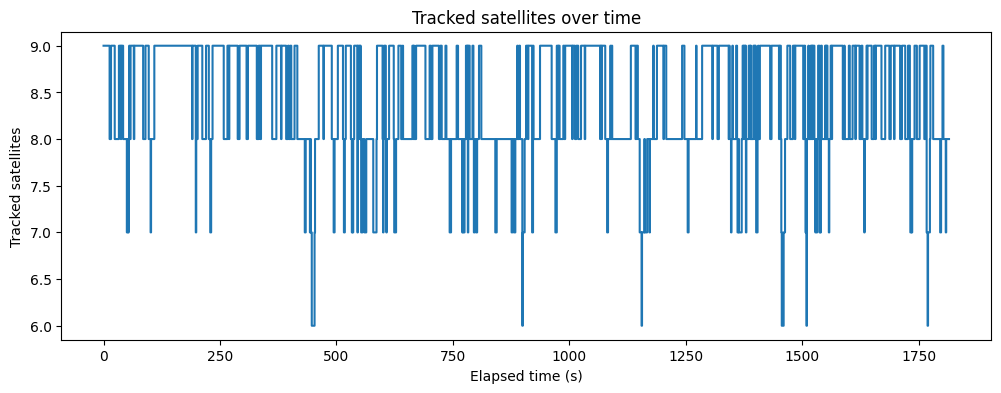

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.step(df["elapsed_s"], df["tracked_satellites"], where="post")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Tracked satellites")
ax.set_title("Tracked satellites over time")
plt.show()

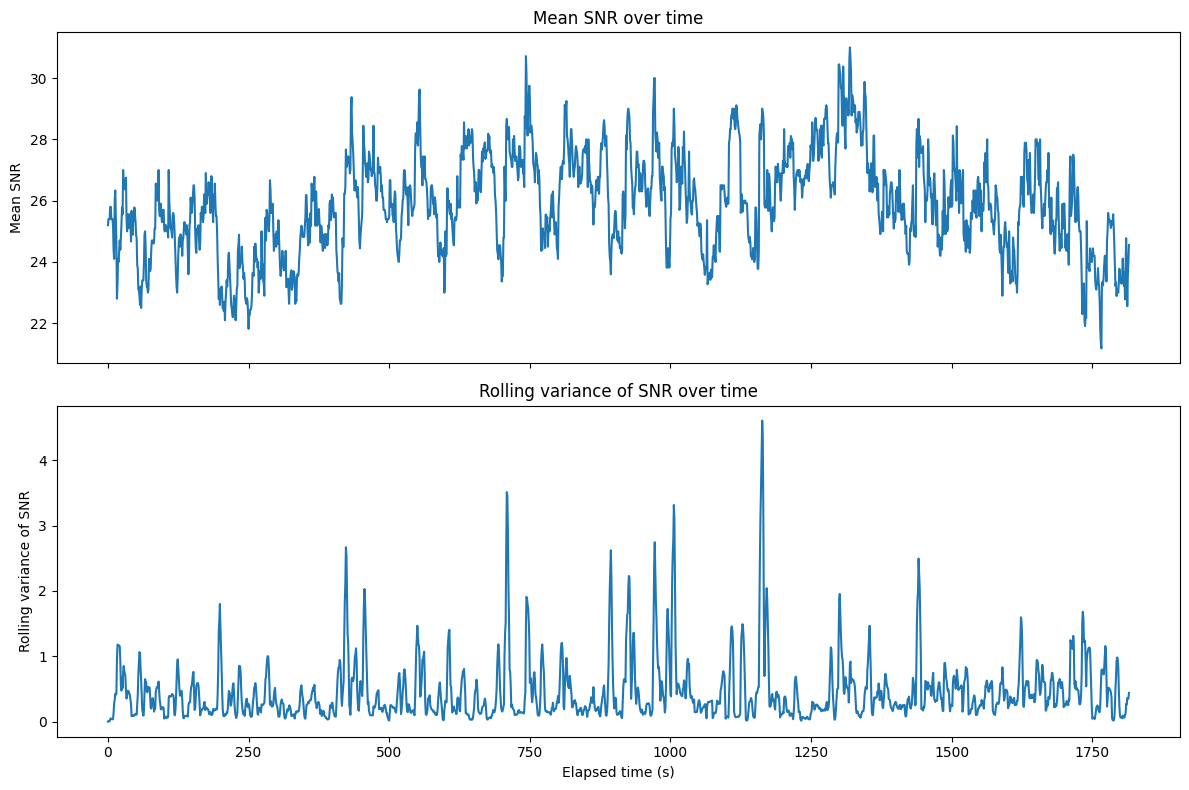

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["elapsed_s"], df["mean_snr"])
axes[0].set_ylabel("Mean SNR")
axes[0].set_title("Mean SNR over time")

axes[1].plot(df["elapsed_s"], df["rolling_var_snr"])
axes[1].set_ylabel("Rolling variance of SNR")
axes[1].set_xlabel("Elapsed time (s)")
axes[1].set_title("Rolling variance of SNR over time")

plt.tight_layout()
plt.show()

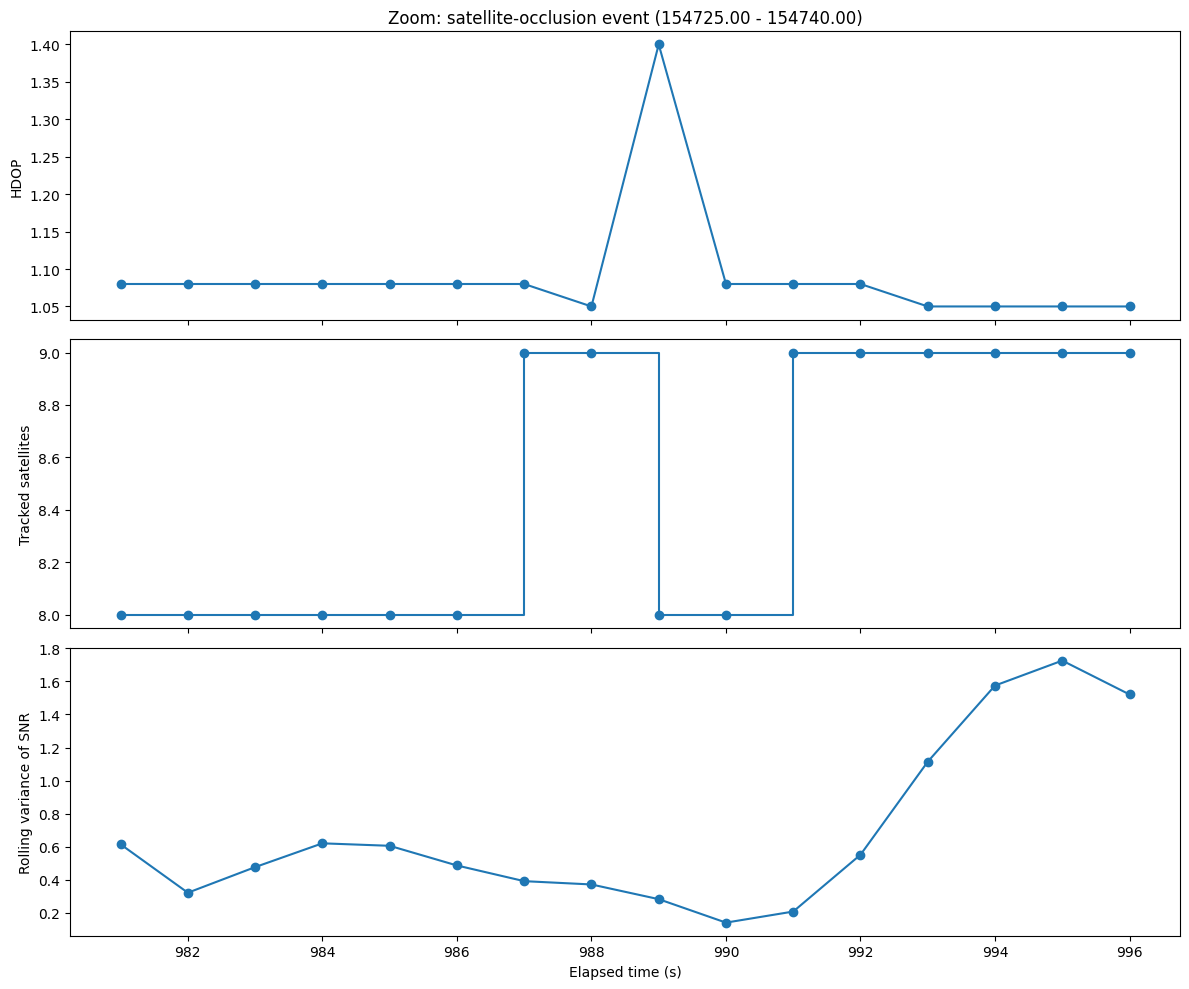

In [6]:
zoom_start = 154725.00
zoom_end = 154740.00

df_zoom = df[(df["fix_time"].astype(float) >= zoom_start) & (df["fix_time"].astype(float) <= zoom_end)]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df_zoom["elapsed_s"], df_zoom["hdop"], marker="o")
axes[0].set_ylabel("HDOP")
axes[0].set_title("Zoom: satellite-occlusion event (154725.00 - 154740.00)")

axes[1].step(df_zoom["elapsed_s"], df_zoom["tracked_satellites"], where="post", marker="o")
axes[1].set_ylabel("Tracked satellites")

axes[2].plot(df_zoom["elapsed_s"], df_zoom["rolling_var_snr"], marker="o")
axes[2].set_ylabel("Rolling variance of SNR")
axes[2].set_xlabel("Elapsed time (s)")

plt.tight_layout()
plt.show()

## What to look for

- **Clean/nominal baseline**: HDOP should sit stable in roughly the **1.0-1.5** range, well below the 2.0 good/fair boundary, with `tracked_satellites` roughly flat and `rolling_var_snr` low and steady.
- **Occlusion signature (zoomed window)**: during the 154725.00-154740.00 window, expect a brief spike in HDOP and/or `rolling_var_snr` and a dip in `tracked_satellites` / `mean_snr`, corresponding to the known satellite-occlusion event. This is the target signature the anomaly detector should learn to flag.